In [57]:
import glob
import math
import os
from pathlib import Path

import ipynbname

primary_path = Path(ipynbname.path()).parent.parent.parent
print("Changing working directory to: ", primary_path)
os.chdir(primary_path)

import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt

from cmcrameri import cm
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LightSource, Colormap, SymLogNorm
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
from tqdm import tqdm

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

Changing working directory to:  /Users/sylvia/dev/aeon


# Helpers

In [63]:
def plot_trisurf_vtu(ax: Axes3D, file: str, field: str, size: float = 10.0, cmap = cm.vik, norm = None):
    vtu = pv.read(file)
    num_points = len(vtu.points[:, 0])

    df = pd.DataFrame(index=range(num_points), columns=["rho", "z", "phi", "lapse"])
    df["rho"] = vtu.points[:, 0]
    df["z"] = vtu.points[:, 1]

    if "Field::Phi0" in vtu.point_data.active_scalars_name:
        df["phi"] = vtu.point_data['Field::Phi0']
        
    df["lapse"] = vtu.point_data['Field::Lapse']
    df["s"] = vtu.point_data['Field::S']
    df["-s"] = -df["s"]

    df = df[(df["rho"] <= size) & (df["z"] <= size)]


    full_rho = np.concatenate((df['rho'], df['rho'], -df['rho'], -df['rho']))
    full_z = np.concatenate((df['z'], -df['z'], -df['z'], df['z']))
    full_phi = np.concatenate((df[field], df[field], df[field], df[field]))

    ls = LightSource(azdeg=225, altdeg=45)

    surf = ax.plot_trisurf(
        full_rho, 
        full_z, 
        full_phi, 
        cmap=cmap, 
        norm = norm,
        # vmin=-0.1, 
        # vmax=0.1,
        edgecolor="white",
        linewidth=0.000,
        antialiased=False,
        # lightsource=ls,
        # shade=True
    )
    return surf

# # make a dictionary containing all of our data 
# field_data = {}
# # loop through VTUs
# for file in glob.glob(data_folder+'/*'):
#     # sub-dictionary for each time step
#     data_time_step = {}
#     time_index = int(file.split('_')[-1].split('.')[0])
#     # read file
#     vtu = pv.read(file)
#     # get data
#     data_time_step['rho'] = vtu.points[:,0]
#     data_time_step['z'] = vtu.points[:,1]
#     data_time_step['Phi'] = vtu.point_data['Field::Phi0']
#     data_time_step['lapse'] = vtu.point_data['Field::Lapse']
#     # update dictionary
#     field_data[time_index] = data_time_step

# Plot Brill Data

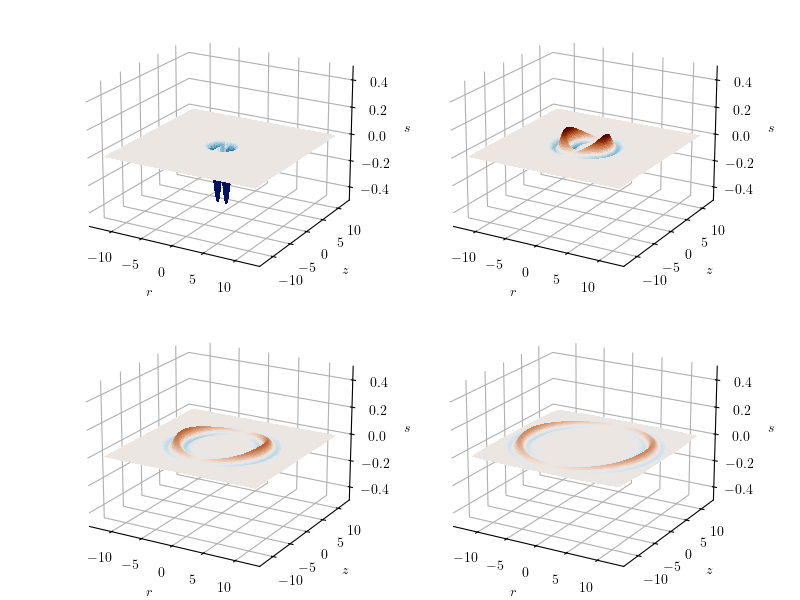

In [46]:
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

evolve_history = pd.read_csv("output/axibrill/1.0/evolve_history.csv")

def index_for_time(proper_time:float):
    return evolve_history[evolve_history["proper_time"] >= proper_time]["output_index"].values[0]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(221, projection="3d")

ax.set_zlim(-0.5,0.5)
# ax.set_axis_off()
ax.view_init(elev=20., azim=120.+180.)
# ax.zaxis.set_ticks_position('none')
ax.set_facecolor('white')
# ax.zaxis.set_ticks_position('none')
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# ax.zaxis.line.set_visible(False)
surf = plot_trisurf_vtu(ax, f"output/axibrill/1.0/evolve/axibrill_{index_for_time(0.0)}.vtu", "s", size=12.5)
# ax.zaxis.set_label_position(None)
# ax.zaxis.set_ticks_position('none')
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$z$")
ax.set_zlabel(r"$s$")

ax = fig.add_subplot(222, projection="3d")
ax.set_zlim(-0.5,0.5)
# ax.set_axis_off()
ax.view_init(elev=20., azim=120.+180.)
# ax.zaxis.set_ticks_position('none')
ax.set_facecolor('white')
# ax.zaxis.set_ticks_position('none')
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# ax.zaxis.line.set_visible(False)
surf = plot_trisurf_vtu(ax, f"output/axibrill/1.0/evolve/axibrill_{index_for_time(3.3)}.vtu", "s", size=12.5)
# ax.zaxis.set_label_position(None)
# ax.zaxis.set_ticks_position('none')
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$z$")
ax.set_zlabel(r"$s$")

ax = fig.add_subplot(223, projection="3d")
ax.set_zlim(-0.5,0.5)
# ax.set_axis_off()
ax.view_init(elev=20., azim=120.+180.)
# ax.zaxis.set_ticks_position('none')
ax.set_facecolor('white')
# ax.zaxis.set_ticks_position('none')
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# ax.zaxis.line.set_visible(False)
surf = plot_trisurf_vtu(ax, f"output/axibrill/1.0/evolve/axibrill_{index_for_time(6.6)}.vtu", "s", size=12.5)
# ax.zaxis.set_label_position(None)
# ax.zaxis.set_ticks_position('none')
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$z$")
ax.set_zlabel(r"$s$")

ax = fig.add_subplot(224, projection="3d")
ax.set_zlim(-0.5,0.5)
# ax.set_axis_off()
ax.view_init(elev=20., azim=120.+180.)
# ax.zaxis.set_ticks_position('none')
ax.set_facecolor('white')
# ax.zaxis.set_ticks_position('none')
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# ax.zaxis.line.set_visible(False)
surf = plot_trisurf_vtu(ax, f"output/axibrill/1.0/evolve/axibrill_{index_for_time(9.9)}.vtu", "s", size=12.5)
# ax.zaxis.set_label_position(None)
# ax.zaxis.set_ticks_position('none')
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$z$")
ax.set_zlabel(r"$s$")


plt.tight_layout(pad=0.0)
# fig.subplots_adjust()
plt.savefig("figures/brill_disperse.png", dpi=500, bbox_inches="tight", pad_inches=0.25)
plt.show()

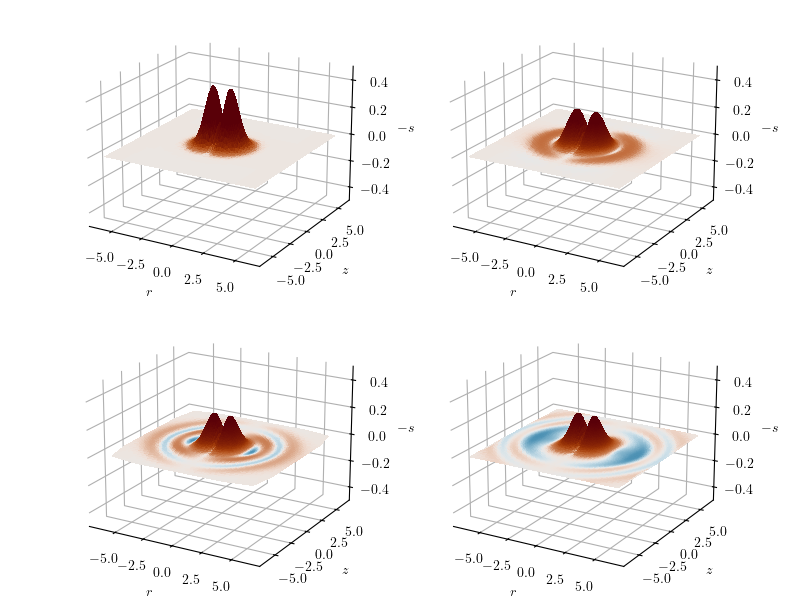

In [75]:
evolve_history = pd.read_csv("output/axibrillalt/1.0/evolve_history.csv")

def index_for_time(proper_time:float):
    return evolve_history[evolve_history["proper_time"] >= proper_time]["output_index"].values[0]

norm = SymLogNorm(linthresh=0.005, vmin=-0.2, vmax=0.2)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(221, projection="3d")

ax.set_zlim(-0.5,0.5)
# ax.set_axis_off()
ax.view_init(elev=20., azim=120.+180.)
# ax.zaxis.set_ticks_position('none')
ax.set_facecolor('white')
# ax.zaxis.set_ticks_position('none')
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# ax.zaxis.line.set_visible(False)
surf = plot_trisurf_vtu(ax, f"output/axibrillalt/1.0/evolve/axibrillalt_{index_for_time(0.0)}.vtu", "-s", size=6.5, norm=norm)
# ax.zaxis.set_label_position(None)
# ax.zaxis.set_ticks_position('none')
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$z$")
ax.set_zlabel(r"$-s$")
ax.set_xticks([-5.0, -2.5, 0.0, 2.5, 5.0])
ax.set_yticks([-5.0, -2.5, 0.0, 2.5, 5.0])

ax = fig.add_subplot(222, projection="3d")
ax.set_zlim(-0.5,0.5)
# ax.set_axis_off()
ax.view_init(elev=20., azim=120.+180.)
# ax.zaxis.set_ticks_position('none')
ax.set_facecolor('white')
# ax.zaxis.set_ticks_position('none')
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# ax.zaxis.line.set_visible(False)
surf = plot_trisurf_vtu(ax, f"output/axibrillalt/1.0/evolve/axibrillalt_{index_for_time(2.0)}.vtu", "-s", size=6.5, norm=norm)
# ax.zaxis.set_label_position(None)
# ax.zaxis.set_ticks_position('none')
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$z$")
ax.set_zlabel(r"$-s$")
ax.set_xticks([-5.0, -2.5, 0.0, 2.5, 5.0])
ax.set_yticks([-5.0, -2.5, 0.0, 2.5, 5.0])

ax = fig.add_subplot(223, projection="3d")
ax.set_zlim(-0.5,0.5)
# ax.set_axis_off()
ax.view_init(elev=20., azim=120.+180.)
# ax.zaxis.set_ticks_position('none')
ax.set_facecolor('white')
# ax.zaxis.set_ticks_position('none')
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# ax.zaxis.line.set_visible(False)
surf = plot_trisurf_vtu(ax, f"output/axibrillalt/1.0/evolve/axibrillalt_{index_for_time(4.0)}.vtu", "-s", size=6.5, norm=norm)
# ax.zaxis.set_label_position(None)
# ax.zaxis.set_ticks_position('none')
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$z$")
ax.set_zlabel(r"$-s$")

ax = fig.add_subplot(224, projection="3d")
ax.set_zlim(-0.5,0.5)
# ax.set_axis_off()
ax.view_init(elev=20., azim=120.+180.)
# ax.zaxis.set_ticks_position('none')
ax.set_facecolor('white')
# ax.zaxis.set_ticks_position('none')
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# ax.zaxis.line.set_visible(False)
surf = plot_trisurf_vtu(ax, f"output/axibrillalt/1.0/evolve/axibrillalt_{index_for_time(6.0)}.vtu", "-s", size=6.5, norm=norm)
# ax.zaxis.set_label_position(None)
# ax.zaxis.set_ticks_position('none')
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$z$")
ax.set_zlabel(r"$-s$")

plt.tight_layout(pad=0.0)
# fig.subplots_adjust()
# plt.savefig("figures/brill_disperse_no_shift.png", dpi=500, bbox_inches="tight", pad_inches=0.25)
plt.show()

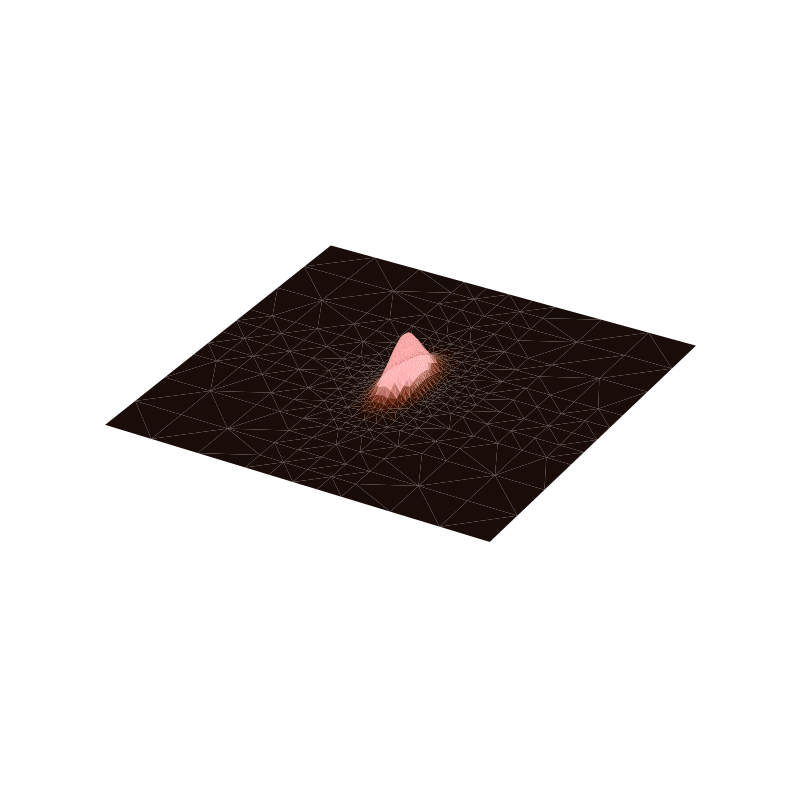

In [ ]:
%matplotlib inline

frame_stat = 0  # which frame to show
field = 'Phi'  # from 'Phi' or 'lapse' as defined in cell 2

# mirror data across both axes
full_rho = np.concatenate((field_data[frame_stat]['rho'], field_data[frame_stat]['rho'], -field_data[frame_stat]['rho'], -field_data[frame_stat]['rho']))
full_z = np.concatenate((field_data[frame_stat]['z'], -field_data[frame_stat]['z'], -field_data[frame_stat]['z'], field_data[frame_stat]['z']))
full_phi = np.concatenate((field_data[frame_stat][field], field_data[frame_stat][field], field_data[frame_stat][field], field_data[frame_stat][field]))

# plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.set_zlim(-1.,1.)
ax.set_axis_off()
ax.view_init(elev=30., azim=120.)

ax.plot_trisurf(full_rho, full_z, full_phi, cmap=cm.berlin, vmin=-0.1, vmax=0.1)

plt.show()

# Show static lapse in some frame

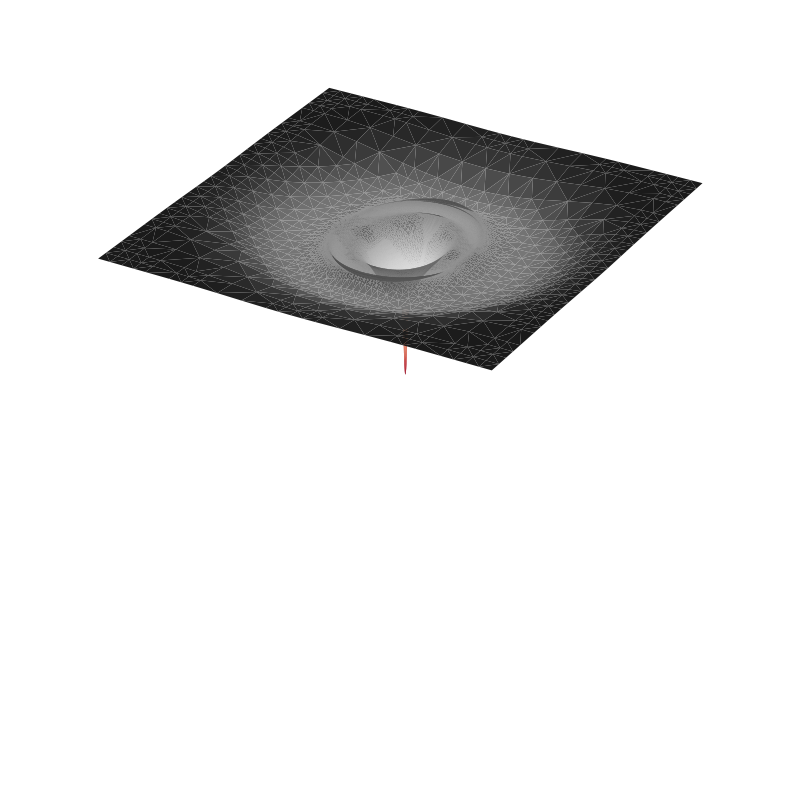

In [17]:
%matplotlib inline

frame_stat = 720  # which frame to show
field = 'lapse'  # from 'Phi' or 'lapse' as defined in cell 2

# mirror data across both axes
full_rho = np.concatenate((field_data[frame_stat]['rho'], field_data[frame_stat]['rho'], -field_data[frame_stat]['rho'], -field_data[frame_stat]['rho']))
full_z = np.concatenate((field_data[frame_stat]['z'], -field_data[frame_stat]['z'], -field_data[frame_stat]['z'], field_data[frame_stat]['z']))
full_phi = np.concatenate((field_data[frame_stat][field], field_data[frame_stat][field], field_data[frame_stat][field], field_data[frame_stat][field]))

# plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.set_zlim(-1.,1.)
ax.set_axis_off()
ax.view_init(elev=30., azim=120.)

ax.plot_trisurf(full_rho, full_z, full_phi, cmap='RdGy', vmin=0., vmax=1.)

plt.show()

# Animation

In [10]:
%matplotlib qt

field = 'lapse'

# set up the figure
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.set_axis_off()
ax.set_zlim(0.,1.)
ax.view_init(elev=30., azim=120.)

# plot the first frame
full_rho = np.concatenate((field_data[0]['rho'], field_data[0]['rho'], -field_data[0]['rho'], -field_data[0]['rho']))
full_z = np.concatenate((field_data[0]['z'], -field_data[0]['z'], -field_data[0]['z'], field_data[0]['z']))
full_phi = np.concatenate((field_data[0][field], field_data[0][field], field_data[0][field], field_data[0][field]))
surface = ax.plot_trisurf(full_rho, full_z, full_phi, cmap='RdGy', vmin=0., vmax=1.)

# animation step
def update(time):
    # remove the previous surface
    global surface
    surface.remove()
    # plot the new surface
    ## (there's probably a faster way to do this than mirroring every single time -- i.e., the next three lines can probably be done once outside to speed things up)
    full_rho = np.concatenate((field_data[time]['rho'], field_data[time]['rho'], -field_data[time]['rho'], -field_data[time]['rho']))
    full_z = np.concatenate((field_data[time]['z'], -field_data[time]['z'], -field_data[time]['z'], field_data[time]['z']))
    full_phi = np.concatenate((field_data[time][field], field_data[time][field], field_data[time][field], field_data[time][field]))
    surface = ax.plot_trisurf(full_rho, full_z, full_phi, cmap='RdGy', vmin=0., vmax=1.)
    
# make a list of frames to plot so the animation slows down towards the end
frames = np.sort(list(field_data.keys()))
u = np.linspace(1, 10, 585) # 585 frames
mapped = np.log(u) / np.log(u[-1])
log_frames = (mapped * (frames[-1] - frames[0]) + frames[0]).astype(int)  # make list
log_frames = np.concatenate( [log_frames, np.full(150, log_frames[-1])] )  # add some extra frozen frames on the end

# plot
anim = FuncAnimation(fig, update, frames=tqdm(log_frames), interval=15)
# plt.show()
writer = PillowWriter(fps=40)
anim.save("2d_anim_single.gif", writer=writer)


  8%|██▉                                 | 60/735 [2:03:57<23:14:26, 123.95s/it]

100%|████████████████████████████████████████▉| 734/735 [38:41<00:05,  5.28s/it]